<a href="https://colab.research.google.com/github/kdrm12/AI-Bootcamp-Notebook/blob/main/06_computer_vision_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project - Computer Vision - CNN

**Instructions for Students:**

Please carefully follow these steps to complete and submit your project:

1. **Make a copy of the Project**: Please make a copy of this project either to your own Google Drive or download locally. Work on the copy of the project. The master project is **Read-Only**, meaning you can edit, but it will not be saved when you close the master project. To avoid total loss of your work, remember to make a copy.

2. **Completing the Project**: You are required to work on and complete all tasks in the provided project. Be disciplined and ensure that you thoroughly engage with each task.
   
3. **Creating a Google Drive Folder**: Each of you must create a new folder on your Google Drive. This will be the repository for all your completed project files, aiding you in keeping your work organized and accessible.
   
4. **Uploading Completed Project**: Upon completion of your project, make sure to upload all necessary files, involving codes, reports, and related documents into the created Google Drive folder. Save this link in the 'Student Identity' section and also provide it as the last parameter in the `submit` function that has been provided.
   
5. **Sharing Folder Link**: You're required to share the link to your project Google Drive folder. This is crucial for the submission and evaluation of your project.
   
6. **Setting Permission to Public**: Please make sure your Google Drive folder is set to public. This allows your instructor to access your solutions and assess your work correctly.

Adhering to these procedures will facilitate a smooth project evaluation process for you and the reviewers.

## Project Description

In this CNN Project, you will create your own custom Image Classification. You can collect a dataset of images you are interested in and train a CNN model to differentiate between them. For example, a model could be trained to distinguish between different types of birds, cars, plants, or any other topic of interest.

## Grading Criteria

There are 4 tasks with 5 criterias for scoring, all except Criteria 3 have the same weight. Each criteria except Criteria 3 will give you either 100 point if you are correct and 0 if you are wrong. The final score for the project will the the average of all 5 criterias from 4 tasks in this project.

* Task-1 Criteria 1: This task will assess your ability to find a good dataset for your model.

* Task-2 Criteria 2: This task will assess your ability to create and save your model for later use in the inference step.

* Task-2 Criteria 3: The task will assess your ability to evaluate your model based on accuracy score of the model. The accuracy score is directly used as the score. Please refrain from overtraining your model to gain 100% accuracy.

* Task-3 Criteria 4: This task will assess your ability to use Gradia as a UI (User Interface).

* Task-4 Criteria 5: This task will assess your ability to publish your model to Huggingface.


## Student Identity

In [ ]:
# @title #### Student Identity
student_id = "REAABPRB" # @param {type:"string"}
name = "Kevin Adrian Manurung" # @param {type:"string"}
drive_link = "https://drive.google.com/drive/folders/1-MKKoKZe_opw1IbmDLUK6mTxHrle1klI?usp=sharing"  # @param {type:"string"}

assignment_id = "00_cnn_project"

## Import Package

In [ ]:
!pip install rggrader
from rggrader import submit, submit_image

In [ ]:
#Write any package/module installation that you need here

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models

import os
import pandas as pd
import kagglehub
from PIL import Image

## Task-1 Load the dataset

In this task, you will prepare and load your dataset. **You can choose any dataset you want**, make sure the data is diverse and large enough to prevent overfitting and improve the model's ability to generalize.

If you are using images from the internet, **please respect copyright and privacy laws**. Creative Commons licenses or public domain images are a safe bet, and many APIs (like the Unsplash API) provide access to a large number of such images.

### 1.1 Optional Custom Dataset
Provided below is a custom dataset template that you may want to use for your code. It's completely optional.

Alternatively, you can review the material on Data Augmentation or read the Pytorch tutorial https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#creating-a-custom-dataset-for-your-files

In [ ]:
#an example of creating our own custom dataset, you can use this if you want/need. Completely optional.
import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = annotations_file
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

### 1.2 Write your code in the block below

In the code block below, prepare and load your dataset. Please include data preprocessing steps such as dividing the dataset into training, validation, and test sets, or data augmentation techniques that you used if any in this section. Do not put the code to build your model here.

Some techniques you may use:
- Find and load existing dataset from Huggingface or Kaggle. (Easy)
- Create your own custom dataset from the images you have in your possesion or internet search and load the dataset. (Hard)
- Etc.

Hint:
- Usually the dataset are loaded into train_dataset and test_dataset

In [ ]:
# Write your data preprocessing code here

# Download dataset
path = kagglehub.dataset_download("alessiocorrado99/animals10")
data_dir = f"{path}/raw-img"

# translate of label
translate_label = {'cane': 'dog',
                'cavallo': 'horse',
                'elefante': 'elephant',
                'farfalla': 'butterfly',
                'gallina': 'chicken',
                'gatto': 'cat',
                'mucca': 'cow',
                'pecora': 'sheep',
                'scoiattolo': 'squirrel',
                'ragno': 'spider'}

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224
    transforms.ToTensor(), # Convert images to tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize images
])

# Load the dataset
Dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# split dataset to train and test
train_size = int(0.8 * len(Dataset))  # 80% for training
test_size = len(Dataset) - train_size  # 20% for testing
train_dataset, test_dataset = random_split(Dataset, [train_size, test_size])

# split train dataset to train and validation
train_size = int(0.8 * len(train_dataset))  # 80% for training
valid_size = len(train_dataset) - train_size  # 20% for validation
train_dataset, valid_dataset = random_split(train_dataset, [train_size, valid_size])

# Create data loaders for the train and test datasets
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 586M/586M [00:08<00:00, 74.6MB/s]

Extracting files...


### 1.3 Submission

You'll submit the link to your dataset for Task-1.

- If you use existing dataset from Kaggle or Huggingface, then you can put the link to those dataset here.

- If you use your own custom dataset, Upload and store the custom dataset in your Google Drive that you shared with us and put the link to the folder containing that dataset here.

In [ ]:
# Submit Method
dataset_link = "https://www.kaggle.com/datasets/alessiocorrado99/animals10" # Put your model link

question_id = "00_cnn_project_dataset"
submit(student_id, name, assignment_id, dataset_link, question_id, drive_link)

'Assignment successfully submitted'

## Task-2 Build your model

In this task, you will now build and save your model. You can either create your own CNN model or choose any pretrained model that you feel is most appropriate for your dataset.

### 2.1 Write your code in the block below

In the code block below, write the code to **create your model, either from scratch or fine tuning a pretrained model**. You will need to write the code for your model definition, such as the layers used, loss function and optimizer. Please include also the training and validation loops.

Make sure you **save your model to a file** and **measure the accuracy of your model**, as this will be submitted for this task.

Some techniques you may use:
- Use pretrained model. (Easy)
- Create a CNN model from scratch. (Hard)
- Etc.

Hint:
- Use GPU in Google Colab, it significantly improves the time taken for training, compared to CPU.
- **Google Colab GPU usage for free-tier have a limit**, which is unknown, so I suggest you try out in CPU mode that your code works without error, then use GPU for traininig.
- If you are going to upload to Huggingface by using the Transformer Trainer during training, make sure you use the Huggingface method. Refer to Transfer Learning section or read the documentation here: https://huggingface.co/docs/transformers/model_sharing

In [ ]:
#Write your code to build your model here

accuracy = 0 #if you change the name of your accuracy variable, change the name also in the submit parameter
n_classes = len(Dataset.classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load model
model = models.resnet18(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, n_classes)
model.to(device)

loss_fn  = torch.nn.CrossEntropyLoss()
learning_rate = 1e-2
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

#define the iteration
ITERATION = 25

# Train Loop
for epoch in range(ITERATION):

    # Train
    total_loss = 0
    total_correct = 0
    total_data = 0
    model.train()
    for features, labels in train_loader:
        # Generate predictions
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        loss = loss_fn(outputs, labels)

        # Perform gradient descent
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # loss
        total_loss += loss.item()

        # accuracy
        _, prediction = torch.max(outputs, 1)
        total_correct += (prediction == labels).sum().item()
        total_data += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_accuracy = total_correct/total_data

    # Validate
    total_loss = 0
    total_correct = 0
    total_data = 0
    model.eval()
    with torch.no_grad():
        for features, labels in valid_loader:
            # Generate predictions
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = loss_fn(outputs, labels)

            # loss
            total_loss += loss.item()

            # accuracy
            _, prediction = torch.max(outputs, 1)
            total_correct += (prediction == labels).sum().item()
            total_data += labels.size(0)

    valid_loss = total_loss / len(valid_loader)
    valid_accuracy = total_correct/total_data
    print('Epoch [{}/{}], Training loss: {:.4f}, Training accuracy: {:.4f}, Validation loss: {:.4f}, Validation accuracy: {:.4f}'.format(epoch+1, ITERATION, train_loss, train_accuracy, valid_loss, valid_accuracy))

# Evaluate performance using testing data
accum_correct = 0
accum_lost = 0
total_data = 0
model.eval()
with torch.no_grad():
    for features, labels in test_loader:
        # Generate predictions
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)

        # loss
        loss = loss_fn(outputs, labels)
        accum_lost += loss.item()

        # accuracy
        _, prediction = torch.max(outputs, 1)
        accum_correct += (prediction == labels).sum().item()
        total_data += labels.size(0)

    accuracy = accum_correct/total_data*100
    print('Test loss: {:.4f}, Test accuracy: {:.4f}%'.format(accum_lost/len(test_loader), accuracy))

# save model
torch.save(model.state_dict(), 'animal_classification_model.pth')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 96.8MB/s]


Epoch [1/25], Training loss: 0.3819, Training accuracy: 0.8941, Validation loss: 0.3372, Validation accuracy: 0.9215
Epoch [2/25], Training loss: 0.3677, Training accuracy: 0.9173, Validation loss: 0.3447, Validation accuracy: 0.9255
Epoch [3/25], Training loss: 0.3554, Training accuracy: 0.9283, Validation loss: 0.3637, Validation accuracy: 0.9418
Epoch [4/25], Training loss: 0.3667, Training accuracy: 0.9312, Validation loss: 0.6755, Validation accuracy: 0.9129
Epoch [5/25], Training loss: 0.3697, Training accuracy: 0.9321, Validation loss: 0.4324, Validation accuracy: 0.9353
Epoch [6/25], Training loss: 0.3797, Training accuracy: 0.9333, Validation loss: 0.4243, Validation accuracy: 0.9377
Epoch [7/25], Training loss: 0.3572, Training accuracy: 0.9416, Validation loss: 0.3974, Validation accuracy: 0.9441
Epoch [8/25], Training loss: 0.3406, Training accuracy: 0.9420, Validation loss: 0.4313, Validation accuracy: 0.9441
Epoch [9/25], Training loss: 0.3677, Training accuracy: 0.9394, 

### 2.2 Submission

You'll submit the link to your model and the accuracy score for your model in this section.

Remember to download or move/upload your model from Google Colab to your Google Drive. Put the link to the Google Drive for your model below.

If you use a different variable to store your accuracy, remember to also change the `accuracy` variable below.

In [ ]:
# Submit Method
model_link = "https://drive.google.com/drive/folders/1Kogj3oenGsjUBAHj22s4X0APvIkX79h-?usp=sharing" # Put your model link

question_id = "01_cnn_project_model_link"
submit(student_id, name, assignment_id, model_link, question_id, drive_link)
question_id = "02_cnn_project_model_accuracy"
submit(student_id, name, assignment_id, str(accuracy), question_id, drive_link)

'Assignment successfully submitted'

## Task-3 Model Inference

In this task, you will be exercising the application of your model, or as it's commonly referred to in AI terminology, you will be performing inference using your model.

Simply load your saved model from Task-2 and create an inference for the model. Where you'll feed an image as input and the model will output the label as well as the percentage of confidence for the label.

### 3.1 Write your code in the block below

In the code block below write the code to use the model you created in Task-2. Load the model and input image, afterwards, show the result of the label/class together with confidence level in percentage as well as the input image.

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
<ipython-input-25-5f396517c4a8>:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more detai

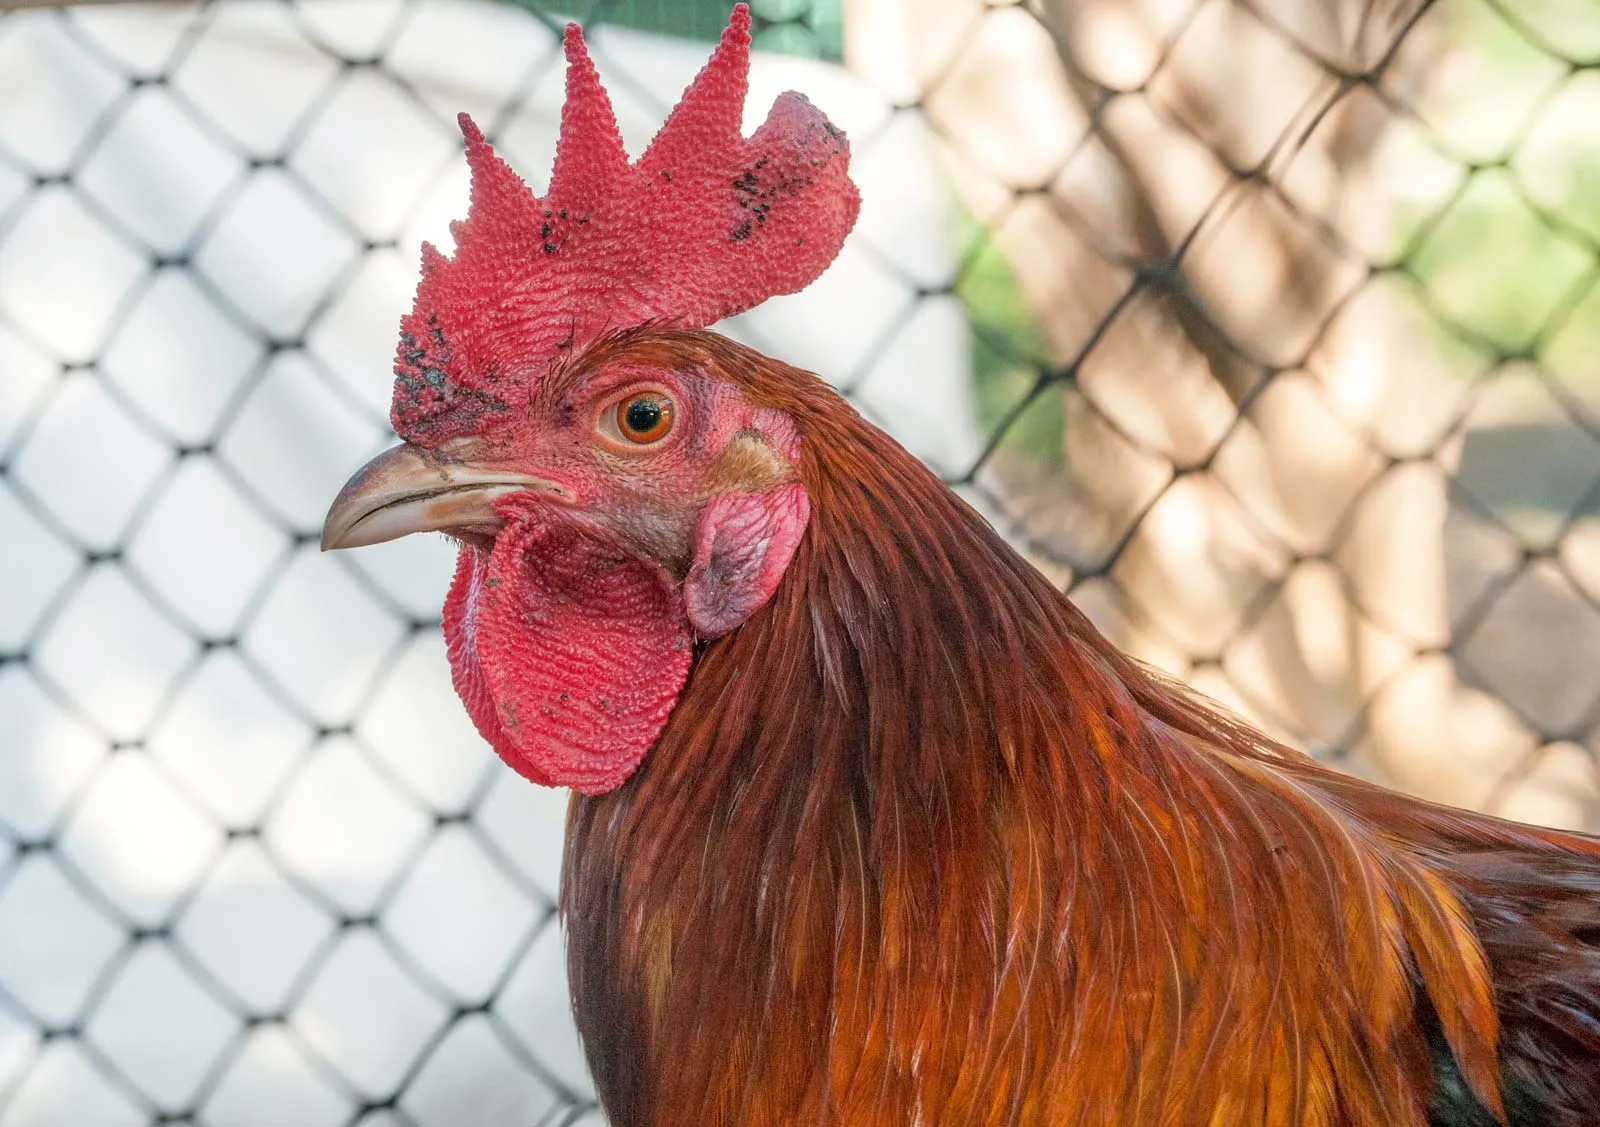

predicted: chicken (confidence: 100.00%)


In [ ]:
#Write your code for inference here
# Put your code here:

# translate of label
translate_label = {'cane': 'dog',
                'cavallo': 'horse',
                'elefante': 'elephant',
                'farfalla': 'butterfly',
                'gallina': 'chicken',
                'gatto': 'cat',
                'mucca': 'cow',
                'pecora': 'sheep',
                'scoiattolo': 'squirrel',
                'ragno': 'spider'}
n_classes = len(translate_label)

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224
    transforms.ToTensor(), # Convert images to tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize images
])

# load model
pretrained_path = '/content/animal_classification_model.pth'
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, n_classes)
model.load_state_dict(torch.load(pretrained_path, map_location=torch.device('cpu')))

# load image
image_path = '/content/image_1.jpg'
input_image = Image.open(image_path)
input_tensor = transform(input_image).unsqueeze(0)

# predict model
model.eval()
with torch.no_grad():
    output = model(input_tensor)
classes = sorted(os.listdir(data_dir))
predicted_class = torch.argmax(output, dim=1).item()
predicted_label = translate_label[classes[predicted_class]]
softmax = torch.nn.Softmax(dim=1)
confidence = torch.max(softmax(output), dim=1).values.item() * 100

display(input_image)
print(f"predicted: {predicted_label} (confidence: {confidence:.2f}%)")

# ---- End of your code ----


### 3.2 Submission

You'll submit a screenshot of your inference in this section. Remember to save the screenshot first before submitting it.

Hint:

![Upload colab](https://storage.googleapis.com/rg-ai-bootcamp/project-3-pipeline-and-gradio/upload-colab.png)

- In Google Colab you can just use the "Folder" sidebar and click the upload button. Make sure your screenshot match below requirements:

    - Image name screenshot is `submission.jpg`. If you change the name of the screenshot  file, change it also in the submit_image parameter.
    - The input image and label as well as percentage of confidence should be included in the screenshot

Here is an example of a correct screenshot:

![Screenshot submission sammple - hummer](https://storage.googleapis.com/rg-ai-bootcamp/projects/project-5-cnn-hummer.png)

In [ ]:
# Submit Method

question_id = "03_cnn_project_inference"
submit_image(student_id, question_id, './submission.jpg')

'Assignment successfully submitted'

## Task-4 Model Publishing

In this task, you will push your model to Huggingface. Once you've pushed your model to the Hugging Face Model Hub, you'll have a link that points directly to your model's page. You can share this link with others, and they can use it to directly load your model for their own uses.

### 4.1 Write your code in the block below

In the code block below, write the code to push your model to Huggingface. There are several methods to do this, please refer to the documentation: https://huggingface.co/docs/transformers/model_sharing

Some techniques you may use:
- If you use the Transformer Trainer during the training loop when you create your model above, then you can simply put your `trainer.push_to_hub()` here.
- You can also use the web interface on Huggingface.

Hint:
- Remember to login first to your Huggingface account.
- If you are pushing programmaticaly, then use the huggingface-cli to login.

In [ ]:
from huggingface_hub import login, create_repo, HfApi
login()

In [ ]:
#Write your code for publishing here
# Put your code here:

create_repo("animal_classification", private=False)
os.makedirs('model', exist_ok=True)
!cp /content/animal_classification_model.pth /content/model/animal_classification_model.pth
api = HfApi()
api.upload_folder(
    folder_path="./model",
    repo_id="kdrianm/animal_classification",
    commit_message="Initial commit"
)

# ---- End of your code ----


animal_classification_model.pth:   0%|          | 0.00/44.8M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/kdrianm/animal_classification/commit/7cbe44f55750f4227675075a6680789a5d7698dd', commit_message='Initial commit', commit_description='', oid='7cbe44f55750f4227675075a6680789a5d7698dd', pr_url=None, repo_url=RepoUrl('https://huggingface.co/kdrianm/animal_classification', endpoint='https://huggingface.co', repo_type='model', repo_id='kdrianm/animal_classification'), pr_revision=None, pr_num=None)

### 4.2 Submission

You'll submit a a link to your huggingface model in this section.

The following link is an example of what a trained model's page looks like: https://huggingface.co/aditira/emotion_classification. This is not your model, but rather an example of what your final result might resemble.

Remember, for this project you should push your output model to your own Hugging Face account. The link for your model will be different and should reflect your own username and model name.

In [ ]:
# Submit Method
huggingface_model_link = "https://huggingface.co/kdrianm/animal_classification" # Put your model link

question_id = "04_cnn_project_publish"
submit(student_id, name, assignment_id, huggingface_model_link, question_id, drive_link)

'Assignment successfully submitted'

FIN